In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [ ]:
path = '/content/drive/MyDrive/Merged_1.csv'

In [ ]:
data = pd.read_csv(path)

In [ ]:
data.shape

(21996, 22)

In [ ]:
data = data.drop(['country_region', 'date.1'], axis=1)
data = data.rename(columns={
    'location.1': 'Country',
    'total_deaths': 'daily Deaths',
    'date': 'Date',
    'individualism': 'Individualism',
    'masculinity': 'Masculinity',
    'powerdistance': 'Power Distance',
    'uncertaintyavoidance': 'Uncertainty Avoidance',
    'longtermorientation': 'Long Term Orientation',
    'democracyindex2021': 'Democracy Index',
    'indulgence': 'Indulgence',
    'gdp_per_capita': 'GDP (per capita)',
    'aged_65_older': 'Aged 65 Older',
    'stringency_index': 'Stringency Index',
    'population': 'Population',
    'retail_and_recreation_percent_change_from_baseline': 'Retail and Recreation',
    'grocery_and_pharmacy_percent_change_from_baseline': 'Grocery and Pharmacy',
    'parks_percent_change_from_baseline': 'Parks',
    'transit_stations_percent_change_from_baseline': 'Transit Stations',
    'workplaces_percent_change_from_baseline': 'Workplaces',
    'residential_percent_change_from_baseline': 'Residential'
})
df = data
df.head()

,Country,daily Deaths,Date,Individualism,Masculinity,Power Distance,Indulgence,Uncertainty Avoidance,Long Term Orientation,Democracy Index,GDP (per capita),Aged 65 Older,Stringency Index,Population,Retail and Recreation,Grocery and Pharmacy,Parks,Transit Stations,Workplaces,Residential
0,Angola,NaN,25/03/2020,18,20,83,83,60,15,3,5819,2,33,33933611,-22.0,1.0,-24.0,-41.0,-22.0,15.0
1,Angola,NaN,26/03/2020,18,20,83,83,60,15,3,5819,2,33,33933611,-10.0,23.0,-9.0,-25.0,-27.0,11.0
2,Angola,NaN,27/03/2020,18,20,83,83,60,15,3,5819,2,91,33933611,-48.0,-22.0,-32.0,-52.0,-47.0,26.0
3,Angola,NaN,28/03/2020,18,20,83,83,60,15,3,5819,2,91,33933611,-51.0,-33.0,-28.0,-41.0,-22.0,20.0
4,Angola,2.0,29/03/2020,18,20,83,83,60,15,3,5819,2,91,33933611,-61.0,-40.0,-39.0,-57.0,-11.0,22.0


In [ ]:

                                                                                                                          # Ensure your DataFrame is loaded as df
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values(['Country', 'Date'], inplace=True)
df['time_step'] = df.groupby('Country').cumcount()

                                                                                                                        # Encode countries
country_encoder = LabelEncoder()
df['Country_encoded'] = country_encoder.fit_transform(df['Country'])

                                                                                                                         # Feature groups
fixed_features = ['Individualism', 'Masculinity', 'Power Distance', 'Indulgence',
                  'Uncertainty Avoidance', 'Long Term Orientation',
                  'Population']                                                                                           #'GDP (per capita)', 'Aged 65 Older', 'Democracy Index',



                                                                                                                                # Scaling
scaler_fixed = StandardScaler()
scaler_time = StandardScaler()

# Scaling
#scaler_fixed = MinMaxScaler()
#scaler_time = MinMaxScaler()



df[fixed_features] = scaler_fixed.fit_transform(df[fixed_features])

#for f in time_series_features:
 #   df[f] = df.groupby('Country')[f].transform(
 #       lambda x: scaler_time.fit_transform(x.values.reshape(-1, 1)).flatten())

                                                                                                                                  # Mobility interpolation
#mobility_features = ['Retail and Recreation', 'Grocery and Pharmacy', 'Parks',
                #     'Transit Stations', 'Workplaces', 'Residential']
#for col in mobility_features:
#    df[col] = df.groupby('Country')[col].transform(lambda x: x.interpolate().ffill().bfill())

# Normalize deaths
#df['Cumulative Deaths'] = df['Cumulative Deaths'].fillna(0)
#df['Cumulative Deaths'] = df.groupby('Country')['Cumulative Deaths'].diff().fillna(0)

/tmp/ipykernel_14267/1913373994.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [ ]:
fixed_features = [
    'Individualism', 'Masculinity', 'Power Distance', 'Indulgence',
    'Uncertainty Avoidance', 'Long Term Orientation'
]


In [ ]:
X_fixed = df[fixed_features].values
y = df['daily Deaths'].values


In [ ]:
df['daily Deaths'].isna().sum(), df['daily Deaths'].describe()


(np.int64(148),
 count     21848.000000
 mean       9893.509566
 std       28671.150698
 min           1.000000
 25%         100.000000
 50%         725.000000
 75%        5993.000000
 max      349854.000000
 Name: daily Deaths, dtype: float64)

In [ ]:
                                                                                                                            # Drop rows with missing deaths
df = df.dropna(subset=['daily Deaths'])

                                                                                                                             # OR replace NaN with 0
df['daily Deaths'] = df['daily Deaths'].fillna(0)

                                                                                                                              # Ensure no inf values
df['daily Deaths'].replace([np.inf, -np.inf], np.nan, inplace=True)
df['daily Deaths'] = df['daily Deaths'].fillna(0)


/tmp/ipykernel_14267/1619671405.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['daily Deaths'] = df['daily Deaths'].fillna(0)
/tmp/ipykernel_14267/1619671405.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['daily Deaths'].replace([np.inf, -np.inf], np.nan, inplace=True)
/t

In [ ]:
X_fixed = df[fixed_features].values
y = df['daily Deaths'].values


In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
model.fit(X_fixed, y)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from xgboost import XGBRegressor

                                                                                                                                    # Train a model only on fixed features
model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, random_state=42)
model.fit(X_fixed, y)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

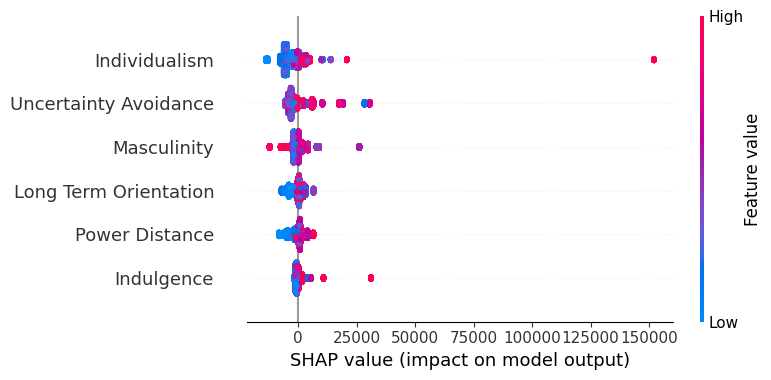

In [ ]:
import shap

                                                                                                                                    # Explainer for tree models
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_fixed)

                                                                                                                                       # Feature importance (global)
shap.summary_plot(shap_values, X_fixed, feature_names=fixed_features)


In [ ]:
import shap

expl = shap.Explanation(
    values=shap_values_ordered,
    data=X_fixed_ordered,
    feature_names=desired_order
)

In [ ]:
#shap.dependence_plot("Individualism", shap_values, X_fixed, feature_names=fixed_features)


In [ ]:
"""
import statsmodels.api as sm

                                                                                                                                          # Reuse your dataset
X_fixed = df[fixed_features]
y = df['daily Deaths']

                                                                                                                                             # Add constant for intercept
X_fixed_const = sm.add_constant(X_fixed)

                                                                                                                                            # Fit OLS regression
ols_model = sm.OLS(y, X_fixed_const).fit()

print(ols_model.summary())
"""

"\nimport statsmodels.api as sm\n\n                                                                                                                                          # Reuse your dataset\nX_fixed = df[fixed_features]\ny = df['daily Deaths']\n\n                                                                                                                                             # Add constant for intercept\nX_fixed_const = sm.add_constant(X_fixed)\n\n                                                                                                                                            # Fit OLS regression\nols_model = sm.OLS(y, X_fixed_const).fit()\n\nprint(ols_model.summary())\n"

=== Mean absolute SHAP values ===
                 Feature  MeanAbsSHAP
0          Individualism  6200.010742
4  Uncertainty Avoidance  4104.670410
1            Masculinity  2320.751221
5  Long Term Orientation  1617.159058
2         Power Distance  1591.000122
3             Indulgence  1411.383057


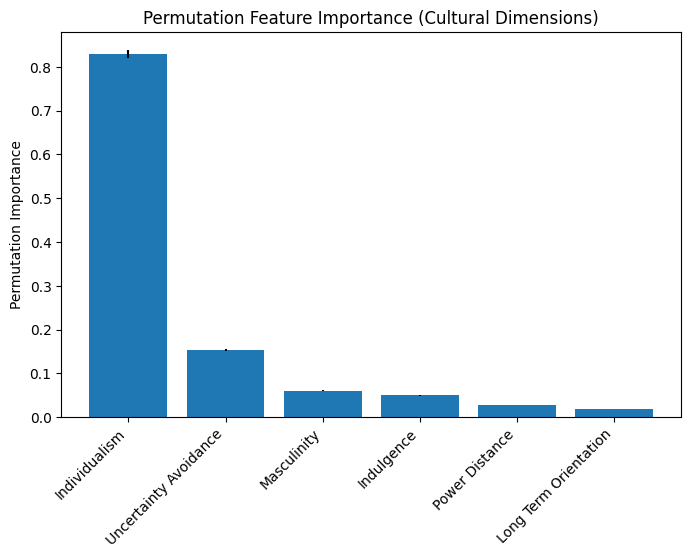

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

                                                                                                                             # Prepare fixed features + target
X_fixed = df[fixed_features].values
y = df['daily Deaths'].values

                                  # If your fixed features list is in fixed_features:
X_fixed_df = pd.DataFrame(X_fixed, columns=fixed_features)

# Now compute SHAP summary properly
shap_importance = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": fixed_features,
    "MeanAbsSHAP": shap_importance
}).sort_values(by="MeanAbsSHAP", ascending=False)

print("=== Mean absolute SHAP values ===")
print(shap_importance_df)
                                                                                          # Fit the model again if not already fitted
from xgboost import XGBRegressor
model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=4, random_state=42)
model.fit(X_fixed, y)

                                                                                                                               # Permutation importance
result = permutation_importance(model, X_fixed, y, n_repeats=10, random_state=42, n_jobs=-1)

                                                                                                                               # Extract importance scores
importances = result.importances_mean
stds = result.importances_std

                                                                                                                                 # Plot
sorted_idx = importances.argsort()[::-1]
plt.figure(figsize=(8, 5))
plt.bar(range(len(fixed_features)), importances[sorted_idx], yerr=stds[sorted_idx], align="center")
plt.xticks(range(len(fixed_features)), [fixed_features[i] for i in sorted_idx], rotation=45, ha="right")
plt.ylabel("Permutation Importance")
plt.title("Permutation Feature Importance (Cultural Dimensions)")
plt.show()


In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score
import numpy as np

X = df[fixed_features].values
y = df['daily Deaths'].values

                                                                                                                              # baseline score (R2)
baseline = model.score(X, y)                                                                                                      # or r2_score(y, model.predict(X))
print("Baseline R2:", baseline)

res = permutation_importance(model, X, y, n_repeats=20, random_state=42, n_jobs=-1, scoring=None)
                                                                                                                         # res.importances_mean is baseline_score - permuted_score (if scoring=None it uses estimator.score)

for feat, imp_mean, imp_std in zip(fixed_features, res.importances_mean, res.importances_std):
    pct_drop = 100 * (imp_mean / baseline) if baseline != 0 else np.nan
    print(f"{feat}: mean_drop={imp_mean:.4f}, std={imp_std:.4f}, pct_of_baseline={pct_drop:.1f}%")


Baseline R2: 0.7111217355490331
Individualism: mean_drop=0.8269, std=0.0091, pct_of_baseline=116.3%
Masculinity: mean_drop=0.0607, std=0.0017, pct_of_baseline=8.5%
Power Distance: mean_drop=0.0284, std=0.0006, pct_of_baseline=4.0%
Indulgence: mean_drop=0.0504, std=0.0015, pct_of_baseline=7.1%
Uncertainty Avoidance: mean_drop=0.1539, std=0.0021, pct_of_baseline=21.6%
Long Term Orientation: mean_drop=0.0183, std=0.0007, pct_of_baseline=2.6%


In [ ]:
import pandas as pd
import numpy as np

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": fixed_features,
    "Mean Importance": res.importances_mean,
    "Std Dev": res.importances_std,
    "Pct of Baseline (%)": [
        100 * (imp / baseline) if baseline != 0 else np.nan
        for imp in res.importances_mean
    ]
})

# Sort (optional)
importance_df = importance_df.sort_values(by="Mean Importance", ascending=False)

# Save to CSV
importance_df.to_csv("permutation_importance.csv", index=False)

print(importance_df)

                 Feature  Mean Importance   Std Dev  Pct of Baseline (%)
0          Individualism         0.826935  0.009081           116.285959
4  Uncertainty Avoidance         0.153922  0.002115            21.644925
1            Masculinity         0.060723  0.001658             8.538975
3             Indulgence         0.050413  0.001450             7.089252
2         Power Distance         0.028406  0.000611             3.994517
5  Long Term Orientation         0.018284  0.000722             2.571081


In [ ]:
importance_df.to_excel("permutation_importance.xlsx", index=False)

In [ ]:
from sklearn.inspection import permutation_importance
res_mse = permutation_importance(model, X, y, n_repeats=20, random_state=42,
                                scoring='neg_mean_squared_error', n_jobs=-1)
# note: result will be negative values (because scoring is neg_MSE); you can convert to MSE difference


In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# correlation matrix
print(df[fixed_features].corr())

# VIF
X_df = df[fixed_features].dropna()
vif_data = pd.DataFrame()
vif_data["feature"] = X_df.columns
vif_data["VIF"] = [variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])]
print(vif_data)


                       Individualism  Masculinity  Power Distance  Indulgence  \
Individualism               1.000000     0.098017       -0.690813    0.138516   
Masculinity                 0.098017     1.000000        0.063480    0.075722   
Power Distance             -0.690813     0.063480        1.000000   -0.288169   
Indulgence                  0.138516     0.075722       -0.288169    1.000000   
Uncertainty Avoidance      -0.257377    -0.019593        0.293317   -0.206870   
Long Term Orientation       0.247614    -0.058818       -0.065404   -0.457481   

                       Uncertainty Avoidance  Long Term Orientation  
Individualism                      -0.257377               0.247614  
Masculinity                        -0.019593              -0.058818  
Power Distance                      0.293317              -0.065404  
Indulgence                         -0.206870              -0.457481  
Uncertainty Avoidance               1.000000               0.150604  
Long Term Or

In [ ]:
# If your fixed features list is in fixed_features:
X_fixed_df = pd.DataFrame(X_fixed, columns=fixed_features)

# Now compute SHAP summary properly
shap_importance = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": fixed_features,
    "MeanAbsSHAP": shap_importance
}).sort_values(by="MeanAbsSHAP", ascending=False)

print("=== Mean absolute SHAP values ===")
print(shap_importance_df)


In [ ]:
from sklearn.inspection import permutation_importance

res = permutation_importance(model, X_fixed_df, y, n_repeats=20,
                             random_state=42, n_jobs=-1, scoring=None)

pfi_df = pd.DataFrame({
    "Feature": fixed_features,
    "PFI_mean": res.importances_mean,
    "PFI_std": res.importances_std
}).sort_values(by="PFI_mean", ascending=False)

print("=== Permutation Feature Importance ===")
print(pfi_df)


=== Permutation Feature Importance ===
                 Feature  PFI_mean   PFI_std
0          Individualism  0.826915  0.009081
4  Uncertainty Avoidance  0.153913  0.002111
1            Masculinity  0.060783  0.001656
3             Indulgence  0.050476  0.001449
2         Power Distance  0.028432  0.000610
5  Long Term Orientation  0.018314  0.000720


In [ ]:
"""
# If your fixed features list is in fixed_features:
X_fixed_df = pd.DataFrame(X_fixed, columns=fixed_features)

# Now compute SHAP summary properly
shap_importance = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": fixed_features,
    "MeanAbsSHAP": shap_importance
}).sort_values(by="MeanAbsSHAP", ascending=False)

print("=== Mean absolute SHAP values ===")
print(shap_importance_df)
"""

'\n# If your fixed features list is in fixed_features:\nX_fixed_df = pd.DataFrame(X_fixed, columns=fixed_features)\n\n# Now compute SHAP summary properly\nshap_importance = np.abs(shap_values).mean(axis=0)\n\nshap_importance_df = pd.DataFrame({\n    "Feature": fixed_features,\n    "MeanAbsSHAP": shap_importance\n}).sort_values(by="MeanAbsSHAP", ascending=False)\n\nprint("=== Mean absolute SHAP values ===")\nprint(shap_importance_df)\n'